## Import libraries and download NLTK data
Set up pandas, plotting, text preprocessing helpers, and the required NLTK resources.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split

nltk.download('stopwords')


[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

## Load the raw review dataset
Read the Amazon reviews CSV and inspect its shape, missing values, and score distribution.


In [22]:
df = pd.read_csv('/Users/beethoven/BigData/AmazonReview/FoodReviews/Reviews.csv')

print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nScore distribution:\n{df['Score'].value_counts().sort_index()}")

Shape: (568454, 10)

Null values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


## Create sentiment labels
Convert numeric review scores into negative, neutral, and positive sentiment classes and visualize the balance.


sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64


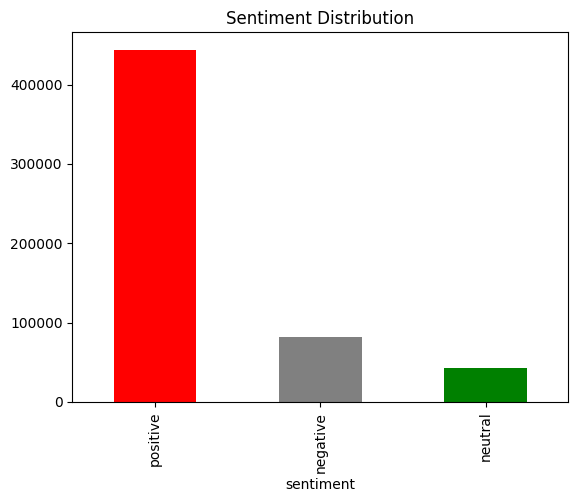

In [23]:
def label_sentiment(score):
    if score < 3:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Score'].apply(label_sentiment)

print(df['sentiment'].value_counts())
df['sentiment'].value_counts().plot(kind='bar', color=['red','gray','green'])
plt.title('Sentiment Distribution')
plt.savefig('../data/sentiment_distribution.png')
plt.show()

## Clean the dataset
Remove rows with missing values and duplicate review text before preprocessing.


In [24]:
df = df.dropna(subset=['Text', 'Score'])
df = df.drop_duplicates(subset=['Text'])
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (393579, 11)


## Define text preprocessing
Build the reusable text cleaning function that lowercases, removes noise, and stems tokens.


In [25]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', '', text)             # remove punctuation/numbers
    tokens = text.split()                              # split into words
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]  # stem + remove stopwords
    return ' '.join(tokens)

## Generate cleaned review text
Apply the preprocessing function to every review and preview the cleaned output.


In [26]:
print("Preprocessing text... this will take a few minutes")
df['clean_text'] = df['Text'].apply(preprocess)
print("Done.")
df[['Text', 'clean_text', 'sentiment']].head(3)

Preprocessing text... this will take a few minutes
Done.


,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought sever vital can dog food product found ...,positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arriv label jumbo salt peanutsth peanu...,negative
2,This is a confection that has been around a fe...,confect around centuri light pillowi citru gel...,positive


## Split and save the data
Create train, validation, and test splits with stratification, then save them to the data folder.


In [27]:
train_val, test = train_test_split(
    df, test_size=0.10, random_state=42, stratify=df['sentiment']
)
train, val = train_test_split(
    train_val, test_size=0.111, random_state=42, stratify=train_val['sentiment']
)

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"\nTrain sentiment:\n{train['sentiment'].value_counts()}")

train.to_csv('../data/train.csv', index=False)
val.to_csv('../data/val.csv', index=False)
test.to_csv('../data/test.csv', index=False)

print("\nFiles saved to /data/")

Train: 314902 | Val: 39319 | Test: 39358

Train sentiment:
sentiment
positive    245437
negative     45659
neutral      23806
Name: count, dtype: int64

Files saved to /data/
